# Effectiveness of thrombolysis in early (4hr) arrivals of mild stroke - discharge mRS 0-2: S-Learner

A 'S-Learner' is a single model that predicts outcome based on patient characteristics and treatment received. It should include all confounders (thoughts factors that affect both outcome and propensity to treat).

## Selection criteria

* Arrival within 4 hours of known stroke onset time
* No thrombectomy
* Stroke type = infarction
* No recorded use of perfusion imaging
* Stroke severity 1-5

## Outcome of interest

* Discharge mRS 0-2.

## Key features of interest

* Onset to thrombolysis time

## Adjustment features used:

* Prior disability
* Stroke severity
* Age
* Congestive heart failure
* Hypertension
* Diabetes
* Atrial fibrillation anticoagulant
* Any atrial fibrillation diagnosis (existing or new)
* Stroke team
* Ethnicity

## Methodology steps

* Select patients by above criteria
* Select features by above criteria
* Split data in 5 sets, where 80% of data is used to train a model, and tets results are generated for the remaining 20% (each patient is in a single test set)
* Train 5 models
* For each model get outcome results for the tets set
* For each model, for patients treated with thrombolysis or thrombectomy, get counterfactual outcomes if they had no treatment
* Calculate the difference between actual outcome and (counterfactual) no-treatment outcomes for treated patients
* Analyse resuls for patients who 1) received thrombectomy only, 2) thrombolysis only, 3) thrombolysis or thrombectomy *

*Note - though the analysis is by different groups, the models are fitted to all groups (no treatment, thrombolysis alone, thrombectomy alone, thrombolysis + thrombectomy).

## Load modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from xgboost import XGBRegressor

# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

## Define mRS outcome target

In [2]:
mrs_target = 2 # Model will set y as being less than or equal to this value

## Define adjustment fields

In [3]:
non_categorical_features = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'onset_to_thrombolysis_time'
    ]

categorical_features = [
    'stroke_team',
    'ethnicity',
]

X_fields = non_categorical_features + categorical_features

## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data_anon_teams.csv", low_memory=False)

# Ensure categorical columns are pandas categorical dtype for XGBoost
for col in categorical_features:
    data[col] = data[col].replace("", "Empty")
    data[col] = data[col].astype("category")

# Ensure non-categorical columns are numeric
for col in non_categorical_features:
    data[col] = pd.to_numeric(data[col], errors="coerce")

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 240 mins
data = data[data["onset_to_arrival_time"] < 240]

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Exlude patients who received thrombectomy
data = data[data["thrombectomy"] == 0]

# Limit to stroke severity  1 - 5 
data = data[(data["stroke_severity"] >= 1) & (data["stroke_severity"] <= 5)]

# Keep only teams with at least 10 onset_to_thrombolysis_time
team_counts = data.groupby("stroke_team")["onset_to_thrombolysis_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")


Initial data shape: (452863, 72)
Final data shape: (58387, 72)
Number of patients with thrombolysis: 13378


## Create 5 k-fold splits

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = data[X_fields]
y = (data['discharge_disability'] <= mrs_target).astype(int)

train_X_sets = []
train_y_sets = []
test_X_sets = []
test_y_sets = []

for train_index, test_index in skf.split(X, y):
    train_X, test_X = X.iloc[train_index], X.iloc[test_index]
    train_y, test_y = y.iloc[train_index], y.iloc[test_index]
    
    train_X_sets.append(train_X)
    train_y_sets.append(train_y)
    test_X_sets.append(test_X)
    test_y_sets.append(test_y)

## Train and test models

In [6]:
models = []
test_y_pred_probas = []
test_y_preds = []

for split in range(5):
    # Get data for this split
    train_X = train_X_sets[split]
    train_y = train_y_sets[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]
    # Get data for weighting
    pos = train_y.sum()
    neg = len(train_y) - pos
    model = XGBClassifier(
        enable_categorical=True,
        verbosity=0,
        seed=42,
        eval_metric='logloss',
        # Scale weight manually adjusted so predictive positive rate
        # matched actual positive rate
        scale_pos_weight=(neg / pos) * 1.15
    )
    # Train model
    model.fit(train_X, train_y)
    models.append(model)
    # Evaluate model with AUC and balanced accuracy
    y_pred_proba = model.predict_proba(test_X)[:, 1]
    y_pred = model.predict(test_X)
    auc = roc_auc_score(test_y, y_pred_proba)
    bal_acc = balanced_accuracy_score(test_y, y_pred)
    test_y_pred_probas.append(y_pred_proba)
    test_y_preds.append(y_pred)
    print(f"Split {split + 1}: AUC = {auc:.4f}, Balanced Accuracy = {bal_acc:.4f}")

Split 1: AUC = 0.7995, Balanced Accuracy = 0.7274
Split 2: AUC = 0.7920, Balanced Accuracy = 0.7225
Split 3: AUC = 0.7934, Balanced Accuracy = 0.7174
Split 4: AUC = 0.7937, Balanced Accuracy = 0.7199
Split 5: AUC = 0.7979, Balanced Accuracy = 0.7190


In [7]:
# Check predicted vs actual positive rates
for split in range(5):
    test_y = test_y_sets[split]
    y_pred_proba = test_y_pred_probas[split]
    y_pred = test_y_preds[split]
    
    actual_pos_rate = test_y.mean()
    predicted_pos_rate = y_pred.mean()
    
    print(f"Split {split + 1}: Actual positive rate = {actual_pos_rate:.4f}, Predicted positive rate = {predicted_pos_rate:.4f}")

Split 1: Actual positive rate = 0.6662, Predicted positive rate = 0.6762
Split 2: Actual positive rate = 0.6661, Predicted positive rate = 0.6724
Split 3: Actual positive rate = 0.6662, Predicted positive rate = 0.6645
Split 4: Actual positive rate = 0.6662, Predicted positive rate = 0.6739
Split 5: Actual positive rate = 0.6662, Predicted positive rate = 0.6701


## Predict counterfactual outcomes

To mimic no thrombolysis or thrombectomy, set times to 99999.

In [8]:
counter_factuals = []

for split in range(5):
    # Get model and data
    model = models[split]
    test_X = test_X_sets[split]
    test_y = test_y_sets[split]

    # Get index of patients who received thrombolysis
    treated_indices = test_X[(test_X['onset_to_thrombolysis_time'] < 99999)].index

    # Get X and y for these patients
    thrombolysis_X = test_X.loc[treated_indices]
    thrombolysis_y = test_y.loc[treated_indices]

    # Get predicted probabilities for these patients
    y_probs = model.predict_proba(thrombolysis_X)[:, 1]
    
    # No thrombolysis scenario: Set onset_to_thrombolysis_time to 99999 for these patients
    no_thrombolysis_X = thrombolysis_X.copy(deep=True)
    no_thrombolysis_X['onset_to_thrombolysis_time'] = 99999
    y_probs_no_thrombolysis = model.predict_proba(no_thrombolysis_X)[:, 1]

    # Combine X, y, and store the counterfactuals for this split
    counter_factuals_split = thrombolysis_X.copy(deep=True)
    counter_factuals_split.insert(0, 'patient_index', treated_indices)
    counter_factuals_split['actual_y'] = thrombolysis_y
    counter_factuals_split['y_prob_treated'] = y_probs
    counter_factuals_split['y_prob_no_thrombolysis'] = y_probs_no_thrombolysis
    counter_factuals_split['treatment_diff_prob'] = y_probs - y_probs_no_thrombolysis
    counter_factuals.append(counter_factuals_split)

    # Convert probabilties to log odds
    counter_factuals_split['log_odds_treated'] = np.log(y_probs / (1 - y_probs))
    counter_factuals_split['log_odds_no_thrombolysis'] = np.log(y_probs_no_thrombolysis / (1 - y_probs_no_thrombolysis))
    counter_factuals_split['log_odds_diff'] = counter_factuals_split['log_odds_treated'] - counter_factuals_split['log_odds_no_thrombolysis']


# Combine all counterfactuals into a single DataFrame
counter_factuals_df = pd.concat(counter_factuals, ignore_index=True)

In [9]:
counter_factuals_df.head(10)

,patient_index,prior_disability,stroke_severity,age,congestive_heart_failure,hypertension,diabetes,afib_anticoagulant,any_afib_diagnosis,onset_to_thrombolysis_time,stroke_team,ethnicity,actual_y,y_prob_treated,y_prob_no_thrombolysis,treatment_diff_prob,log_odds_treated,log_odds_no_thrombolysis,log_odds_diff
0,166,1,5.0,82.5,0.0,1.0,1.0,0.0,0.0,269.0,XYK,White,0,0.261984,0.341717,-0.079733,-1.035682,-0.655654,-0.380029
1,176,0,4.0,77.5,0.0,0.0,0.0,0.0,0.0,275.0,SBH,White,1,0.793287,0.730970,0.062317,1.344855,0.999551,0.345304
2,214,0,3.0,67.5,0.0,1.0,0.0,0.0,0.0,165.0,KAY,White,1,0.450601,0.580389,-0.129788,-0.198245,0.324369,-0.522614
3,347,2,4.0,62.5,0.0,0.0,1.0,0.0,0.0,207.0,WVD,White,0,0.645607,0.552041,0.093566,0.599784,0.208920,0.390864
4,355,1,3.0,47.5,0.0,1.0,0.0,0.0,1.0,122.0,WVO,Other/NK,1,0.818688,0.698922,0.119766,1.507483,0.842168,0.665315
5,364,0,5.0,72.5,0.0,0.0,0.0,0.0,0.0,180.0,JHD,White,1,0.555051,0.611373,-0.056321,0.221102,0.453086,-0.231985
6,372,1,5.0,67.5,0.0,1.0,0.0,0.0,1.0,157.0,KGH,White,1,0.958490,0.812654,0.145835,3.139418,1.467351,1.672066
7,602,0,4.0,52.5,0.0,1.0,0.0,0.0,0.0,212.0,WAN,White,1,0.718300,0.754827,-0.036526,0.936046,1.124522,-0.188476
8,735,1,5.0,77.5,0.0,0.0,1.0,0.0,0.0,199.0,DZA,White,0,0.372110,0.263840,0.108271,-0.523174,-1.026106,0.502932
9,926,0,5.0,67.5,0.0,1.0,1.0,0.0,0.0,260.0,FQE,White,0,0.601525,0.537749,0.063776,0.411822,0.151285,0.260538


In [10]:
counter_factuals_df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_index,13378.0,226606.305427,130539.556981,43.000000,114398.000000,224950.000000,339859.000000,452744.000000
prior_disability,13378.0,0.521079,0.932280,0.000000,0.000000,0.000000,1.000000,5.000000
stroke_severity,13378.0,3.680819,1.194324,1.000000,3.000000,4.000000,5.000000,5.000000
age,13378.0,70.451861,13.090450,37.500000,62.500000,72.500000,82.500000,92.500000
congestive_heart_failure,13378.0,0.034908,0.183554,0.000000,0.000000,0.000000,0.000000,1.000000
hypertension,13378.0,0.512259,0.499868,0.000000,0.000000,1.000000,1.000000,1.000000
diabetes,13378.0,0.189789,0.392149,0.000000,0.000000,0.000000,0.000000,1.000000
afib_anticoagulant,13378.0,0.022574,0.148548,0.000000,0.000000,0.000000,0.000000,1.000000
any_afib_diagnosis,13378.0,0.122589,0.327977,0.000000,0.000000,0.000000,0.000000,1.000000
onset_to_thrombolysis_time,13378.0,177.309389,54.298711,14.000000,136.000000,173.000000,218.000000,358.000000


## Plots of benefit

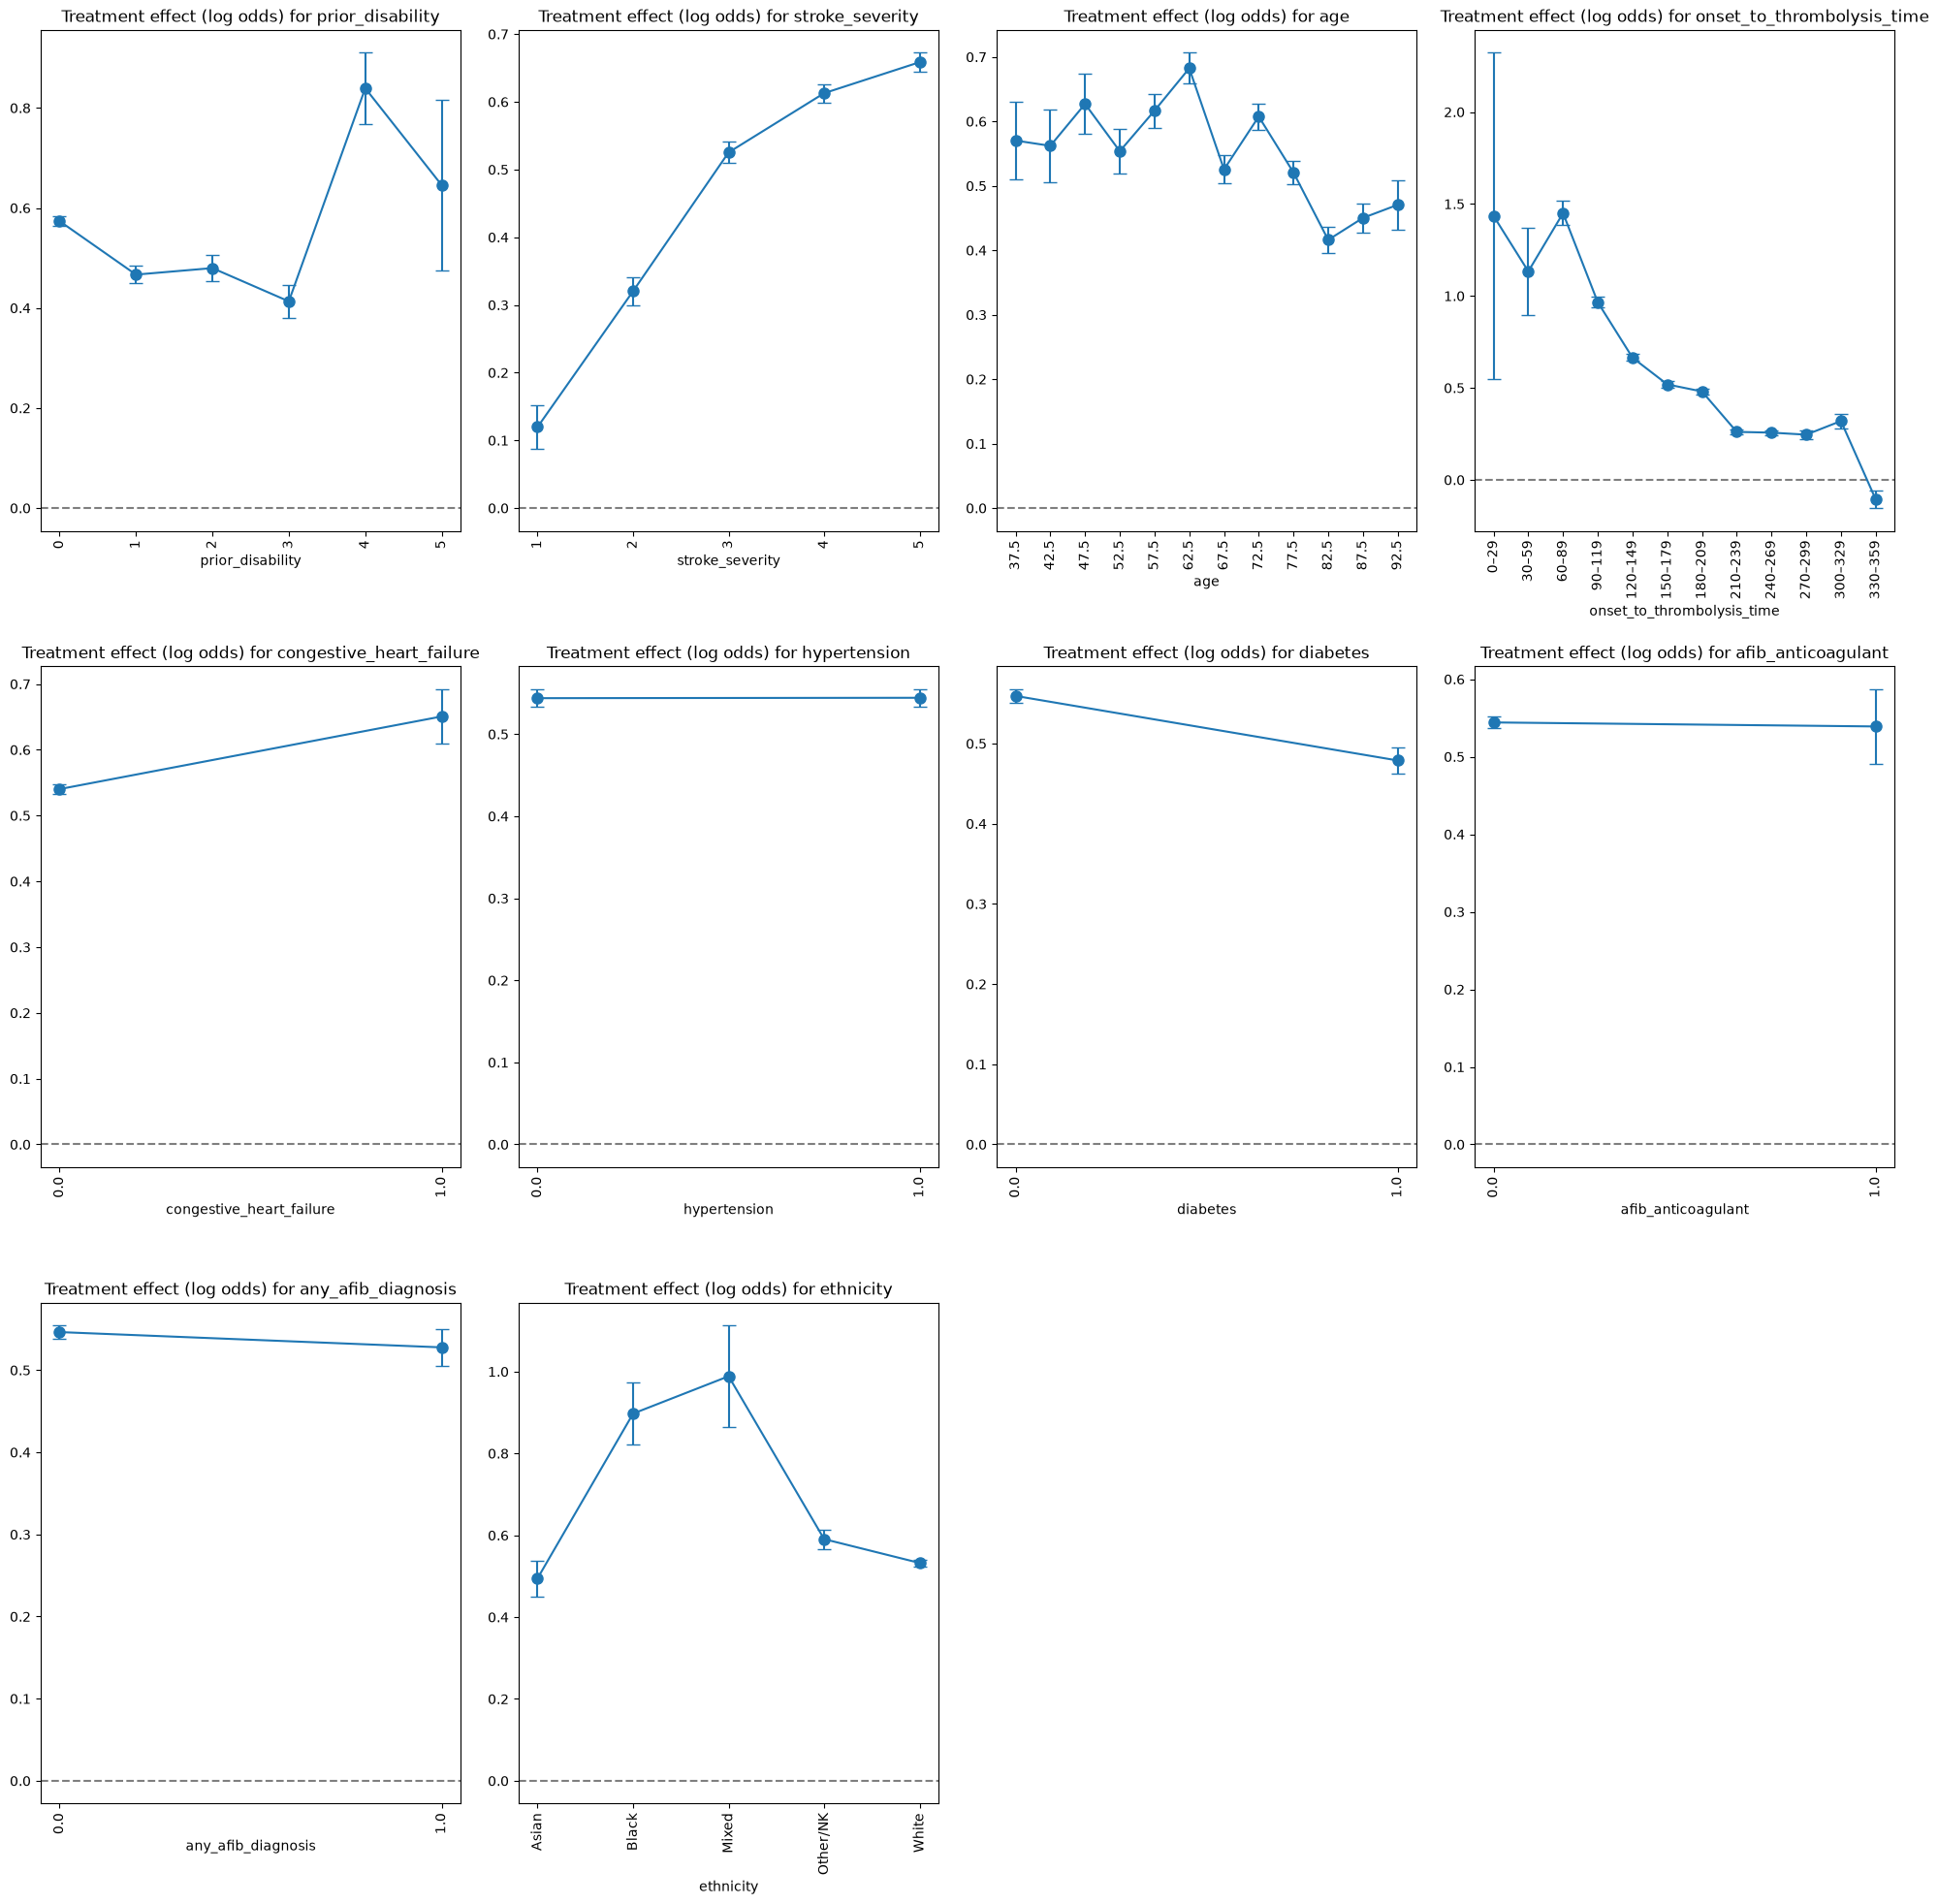

In [11]:
features_to_plot = [
    "prior_disability",
    "stroke_severity",
    "age",
    "onset_to_thrombolysis_time",
    "congestive_heart_failure",
    "hypertension",
    "diabetes",
    "afib_anticoagulant",
    "any_afib_diagnosis",
    "ethnicity",
]

fig, axes = plt.subplots(3, 4, figsize=(20, 20))

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, 4)
    ax = axes[row, col]

    plot_df = counter_factuals_df[
        [feature, "log_odds_diff"]
    ].rename(
        columns={
            feature: "feature_value",
            "log_odds_diff": "effect",
        }
    ).dropna()

    grouped = (
        plot_df.groupby("feature_value", observed=True)["effect"]
        .agg(mean="mean", sem="sem")
    )

    if feature == "stroke_team":
        grouped = grouped.sort_values("mean", ascending=False)

    # If feature is onset_to_thrombolysis_time, bin by 30 minutes
    if feature == "onset_to_thrombolysis_time":
        plot_df["feature_value"] = (
            pd.to_numeric(plot_df["feature_value"]) // 30 * 30
        ).astype(int)

        grouped = (
            plot_df.groupby("feature_value", observed=True)["effect"]
            .agg(mean="mean", sem="sem")
        )

        order = sorted(plot_df["feature_value"].unique())
        time_labels = [
            f"{start}–{start + 29}" for start in order]

    x_values = np.arange(len(grouped))
    labels = [str(value) for value in grouped.index]

    ax.errorbar(
        x_values,
        grouped["mean"],
        yerr=grouped["sem"],
        fmt="o-",
        markersize=8,
        capsize=5,
    )

    ax.set_title(f"Treatment effect (log odds) for {feature}")
    ax.set_xlabel(feature)
    ax.set_xticks(x_values)
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)

    if feature == "stroke_team":
        ax.set_xticklabels([])
    elif feature == "stroke_severity":
        ax.set_xticklabels(
            [f"{float(label):.0f}" for label in labels]
        )
    elif feature == "onset_to_thrombolysis_time":
        ax.set_xticklabels(time_labels)
    else:
        ax.set_xticklabels(labels)

for j in range(len(features_to_plot), axes.size):
    axes.flat[j].axis("off")

plt.tight_layout(pad=2)
plt.savefig(
    f"./output/s_learner_treatment_effects_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## Regression on time to thrombolysis

                            OLS Regression Results                            
Dep. Variable:          log_odds_diff   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     1173.
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          1.95e-246
Time:                        08:11:01   Log-Likelihood:                -16729.
No. Observations:               13378   AIC:                         3.346e+04
Df Residuals:                   13376   BIC:                         3.348e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

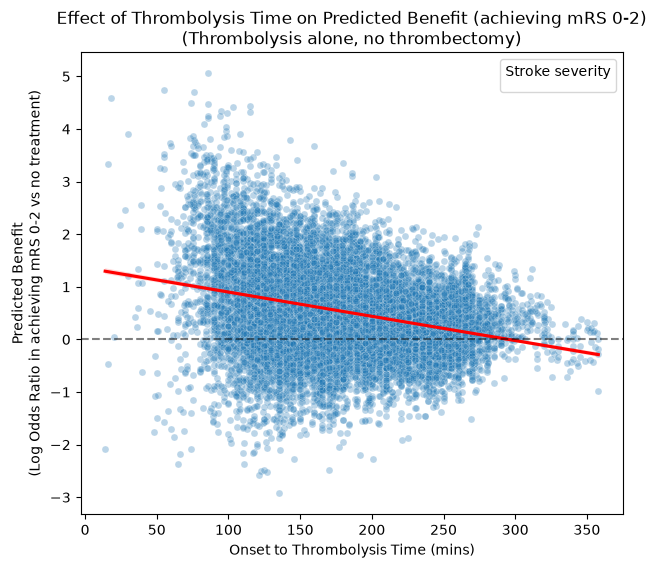

In [12]:
# Fit regression model for predicted benefit vs thrombolysis time
reg_X = counter_factuals_df[["onset_to_thrombolysis_time"]]
reg_y = counter_factuals_df["log_odds_diff"]

reg_X = sm.add_constant(reg_X)
model = sm.OLS(reg_y, reg_X).fit()

print(model.summary())

# Intercept at x = 0 with 95% CI
intercept = model.params["const"]
conf_int = model.conf_int().loc["const"]
print(
    f"\nMax effect (intercept at x=0): {intercept:.4f}, "
    f"95% CI: [{conf_int[0]:.4f}, {conf_int[1]:.4f}]"
)

# Time at which predicted effect is zero: 0 = intercept + slope * x
slope = model.params["onset_to_thrombolysis_time"]

if np.isclose(slope, 0):
    print("Slope is approximately zero, so x at y=0 cannot be estimated reliably.")
else:
    x_at_y0 = -intercept / slope

    cov = model.cov_params()
    var_intercept = cov.loc["const", "const"]
    var_slope = cov.loc[
        "onset_to_thrombolysis_time", "onset_to_thrombolysis_time"
    ]
    cov_intercept_slope = cov.loc["const", "onset_to_thrombolysis_time"]

    var_x_at_y0 = (
        (1 / slope**2) * var_intercept
        + (intercept**2 / slope**4) * var_slope
        - (2 * intercept / slope**3) * cov_intercept_slope
    )
    var_x_at_y0 = max(var_x_at_y0, 0)
    std_x_at_y0 = np.sqrt(var_x_at_y0)

    conf_int_x_at_y0 = (
        x_at_y0 - 1.96 * std_x_at_y0,
        x_at_y0 + 1.96 * std_x_at_y0,
    )
    print(
        f"Time at which effect is zero (x at y=0): {x_at_y0:.0f} mins, "
        f"95% CI: [{conf_int_x_at_y0[0]:.0f}, {conf_int_x_at_y0[1]:.0f}] mins"
    )

# Create a scatter plot with all points in black
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=counter_factuals_df,
    x="onset_to_thrombolysis_time",
    y="log_odds_diff",
#    color="blue",
    s=25,
    alpha=0.3,
)

sns.regplot(
    data=counter_factuals_df,
    x="onset_to_thrombolysis_time",
    y="log_odds_diff",
    scatter=False,
    ci=95,
    line_kws={"color": "red"},
)

plt.legend(title="Stroke severity")

# Add a line at y=0
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.title(
    f"Effect of Thrombolysis Time on Predicted Benefit (achieving mRS 0-{mrs_target})\n"
    "(Thrombolysis alone, no thrombectomy)"
)
plt.xlabel("Onset to Thrombolysis Time (mins)")
plt.ylabel(
    f"Predicted Benefit\n(Log Odds Ratio in achieving mRS 0-{mrs_target} vs no treatment)"
)
plt.savefig(
    f"./output/thrombolysis_time_effect_mrs_{mrs_target}.png", dpi=300, bbox_inches="tight")

plt.show()

Fit regression to each stroke severity.

In [13]:
# Fit regression to each stroke severity (1-5) and store the results
severity_results = {}
for severity in range(1, 6):
    severity_df = counter_factuals_df[counter_factuals_df["stroke_severity"] == severity]
    reg_X = severity_df[["onset_to_thrombolysis_time"]]
    reg_y = severity_df["log_odds_diff"]
    
    reg_X = sm.add_constant(reg_X)
    model = sm.OLS(reg_y, reg_X).fit()
    
    intercept = model.params["const"]
    slope = model.params["onset_to_thrombolysis_time"]
    
    if np.isclose(slope, 0):
        x_at_y0 = None
        conf_int_x_at_y0 = (None, None)
    else:
        x_at_y0 = -intercept / slope
        
        cov = model.cov_params()
        var_intercept = cov.loc["const", "const"]
        var_slope = cov.loc["onset_to_thrombolysis_time", "onset_to_thrombolysis_time"]
        cov_intercept_slope = cov.loc["const", "onset_to_thrombolysis_time"]

        var_x_at_y0 = (
            (1 / slope**2) * var_intercept
            + (intercept**2 / slope**4) * var_slope
            - (2 * intercept / slope**3) * cov_intercept_slope
        )
        var_x_at_y0 = max(var_x_at_y0, 0)
        std_x_at_y0 = np.sqrt(var_x_at_y0)

        conf_int_x_at_y0 = (
            x_at_y0 - 1.96 * std_x_at_y0,
            x_at_y0 + 1.96 * std_x_at_y0,
        )

        # Convert to floatr from np.float64 for better display in DataFrame
        x_at_y0 = round(float(x_at_y0), 1)
        conf_int_x_at_y0 = (
            round(float(conf_int_x_at_y0[0]), 1),
            round(float(conf_int_x_at_y0[1]), 1),
        )
    
    severity_results[severity] = {
        "intercept": intercept,
        "slope": slope,
        "x_at_y0": x_at_y0,
        "conf_int_x_at_y0": conf_int_x_at_y0,
    }

severity_results_df = pd.DataFrame.from_dict(severity_results, orient='index')
severity_results_df.round(3)

,intercept,slope,x_at_y0,conf_int_x_at_y0
1,0.669,-0.003,226.0,"(200.5, 251.5)"
2,0.721,-0.002,326.4,"(275.9, 376.8)"
3,1.276,-0.004,302.4,"(284.0, 320.9)"
4,1.450,-0.005,305.5,"(291.8, 319.2)"
5,1.646,-0.006,291.0,"(280.2, 301.9)"


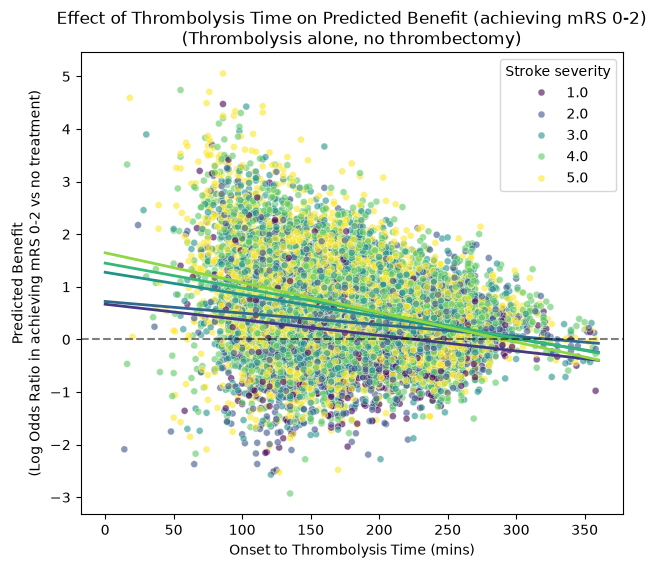

In [14]:
# Create a seaborn scatter plot with regression line and 95% CI
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=counter_factuals_df,
    x="onset_to_thrombolysis_time",
    y="log_odds_diff",
    hue="stroke_severity",
    palette="viridis",
    s=25,
    alpha=0.6,
)

# Add regression line for each stroke severity, based on severity_results_df
x_line = np.linspace(0, 360, 200)
colors = sns.color_palette("viridis", n_colors=5)

for severity, color in zip(range(1, 6), colors):
    result = severity_results_df.loc[severity]

    y_line = result["intercept"] + result["slope"] * x_line

    plt.plot(
        x_line,
        y_line,
        color=color,
        linewidth=2,
    )

plt.legend(title="Stroke severity")

# Add a line at y=0
plt.axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.title(
    f"Effect of Thrombolysis Time on Predicted Benefit (achieving mRS 0-{mrs_target})\n"
    "(Thrombolysis alone, no thrombectomy)"
)
plt.xlabel("Onset to Thrombolysis Time (mins)")
plt.ylabel(
    f"Predicted Benefit\n(Log Odds Ratio in achieving mRS 0-{mrs_target} vs no treatment)"
)
plt.savefig(
    f"./output/thrombolysis_time_effect_by_nihss_mrs_{mrs_target}.png", dpi=300, bbox_inches="tight")

plt.show()


## Meta model of benefit

In [15]:
X = counter_factuals_df[X_fields]
y = counter_factuals_df["log_odds_diff"]

# Ensure categorical features are treated as categorical
for cat_feature in categorical_features:
    X[cat_feature] = X[cat_feature].astype("category")

# Fit XGBoost regression model
model = XGBRegressor(
    enable_categorical=True,
    verbosity=0,
    seed=42,
    eval_metric='rmse'
)
model.fit(X, y)

# Predict log odds shift for the entire dataset
counter_factuals_df["predicted_log_odds_shift"] = model.predict(X)

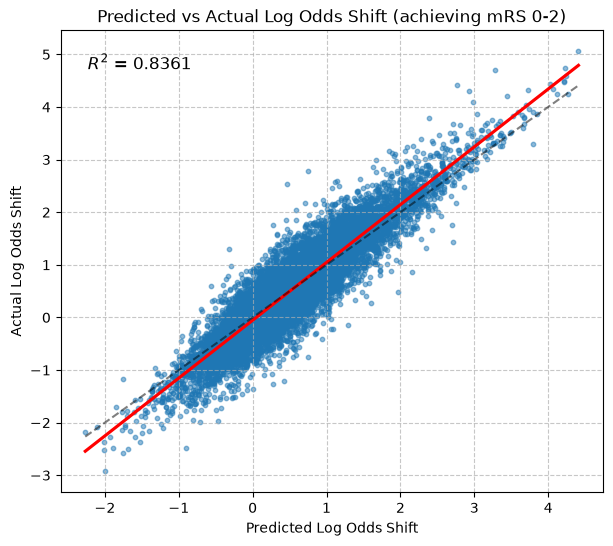

In [16]:
# Plot SEABORN scatter plot with regression line and 95% CI for predicted log odds shift vs actual log odds shift
plt.figure(figsize=(7, 6))
sns.regplot(
    x="predicted_log_odds_shift",
    y="log_odds_diff",
    data=counter_factuals_df,
    ci=95,
    scatter_kws={"s": 10, "alpha": 0.5},
    line_kws={"color": "red"},
)
# Add a line at y=x
plt.plot([counter_factuals_df["predicted_log_odds_shift"].min(), counter_factuals_df["predicted_log_odds_shift"].max()],
         [counter_factuals_df["predicted_log_odds_shift"].min(), counter_factuals_df["predicted_log_odds_shift"].max()],
         color='black', linestyle='--', alpha=0.5)
plt.title(f"Predicted vs Actual Log Odds Shift (achieving mRS 0-{mrs_target})")
plt.xlabel("Predicted Log Odds Shift")
plt.ylabel("Actual Log Odds Shift")
# Add grid lines
plt.grid(axis="both", linestyle="--", alpha=0.7)
# Add r-squared value to the plot
r_squared = model.score(X, y)
plt.text(0.05, 0.95, f"$R^2$ = {r_squared:.4f}", transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig(f"./output/s_learner_predicted_vs_actual_log_odds_shift_{mrs_target}.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# Get SHAP values for the S-learner model
explainer = shap.Explainer(model)
shap_values = explainer(X)

<Axes: xlabel='SHAP value (impact on model output)'>

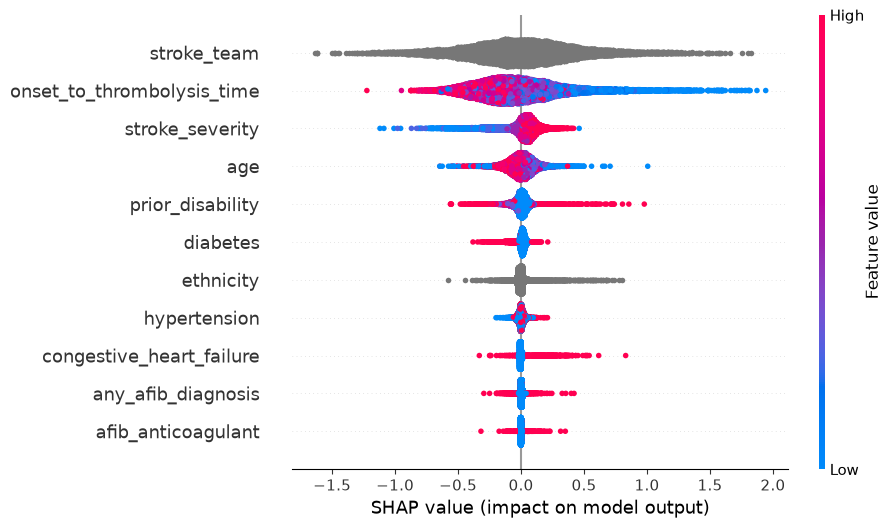

In [18]:
shap.plots.beeswarm(shap_values, max_display=99, show=False)

Plot of SHAP values

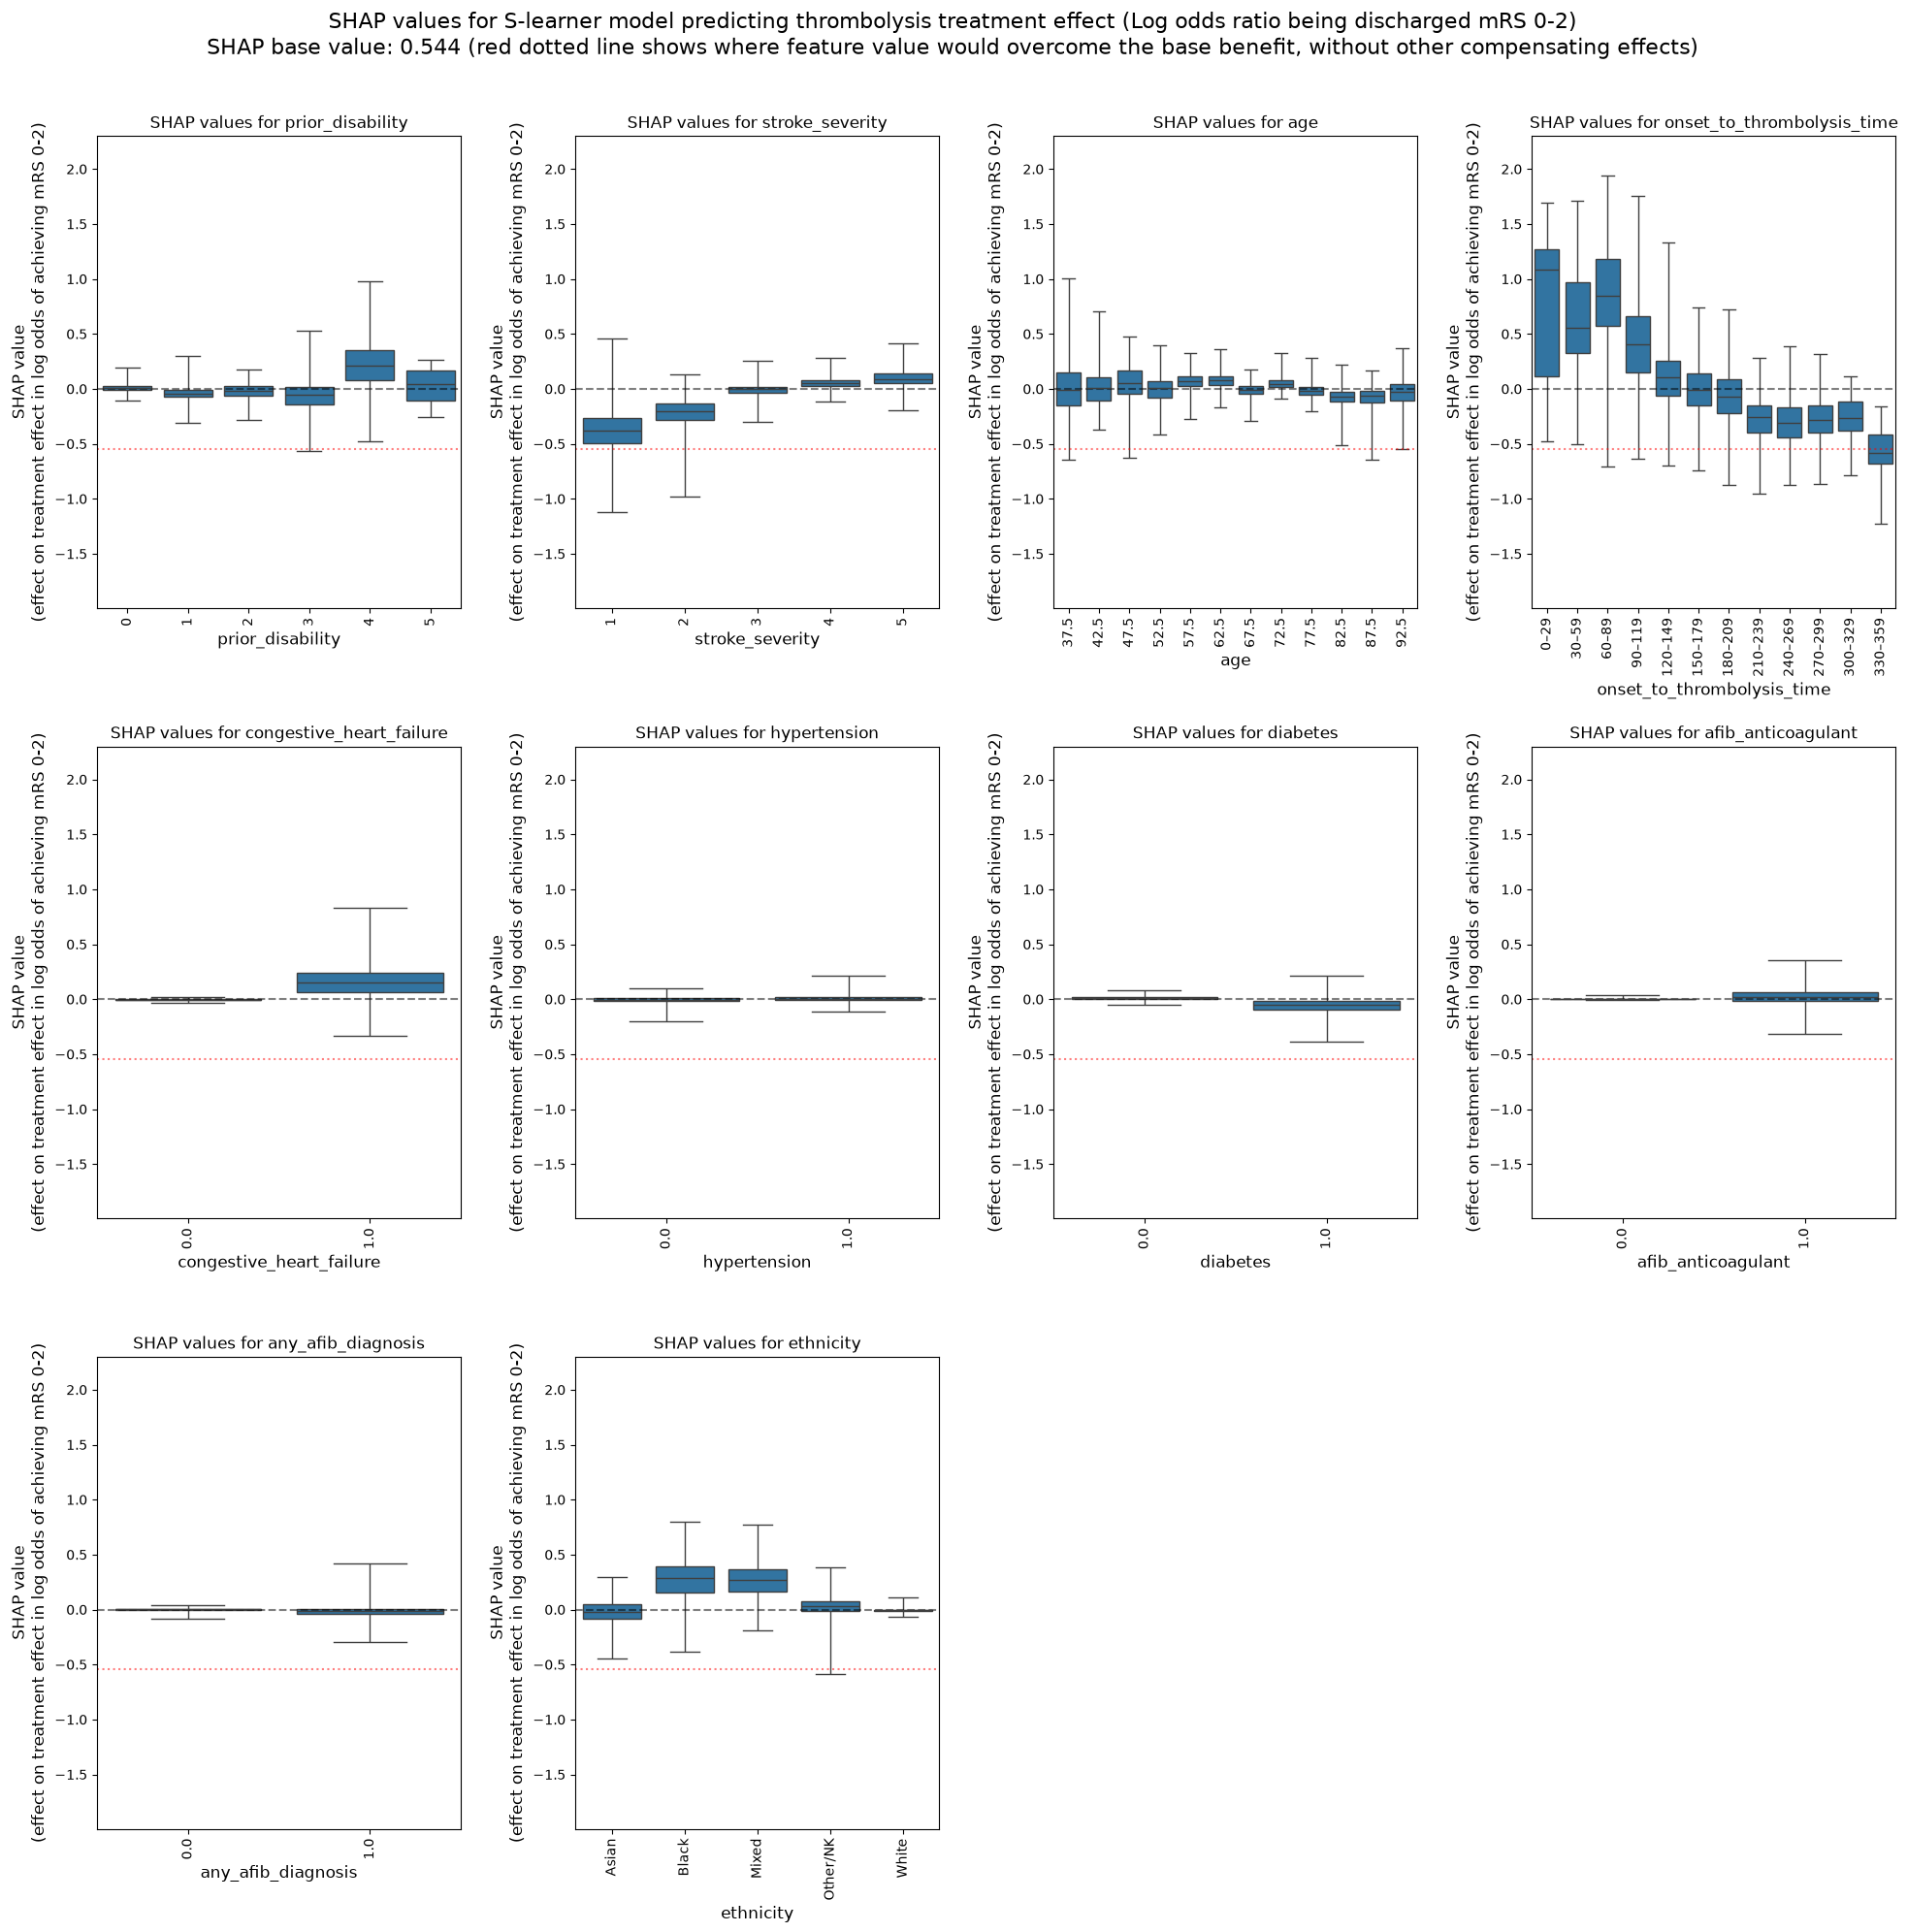

In [19]:
base_value = explainer.expected_value

# Use the features actually present in X and preserve SHAP column alignment.
shap_values_df = pd.DataFrame(
    shap_values.values,
    columns=X.columns,
    index=X.index,
)

mean_abs_shap_values = (
    shap_values_df.abs()
    .mean()
    .sort_values(ascending=False)
)

features_to_plot = [
    "prior_disability",
    "stroke_severity",
    "age",
    "onset_to_thrombolysis_time",
    "congestive_heart_failure",
    "hypertension",
    "diabetes",
    "afib_anticoagulant",
    "any_afib_diagnosis",
    "ethnicity",
]

fig, axes = plt.subplots(3, 4, figsize=(20, 20))
axes = axes.ravel()

min_shap = shap_values_df.min().min()
max_shap = shap_values_df.max().max()
shap_range = max_shap - min_shap
y_limits = (
    min_shap - 0.1 * shap_range,
    max_shap + 0.1 * shap_range,
)

for i, feature in enumerate(features_to_plot):
    ax = axes[i]

    plot_df = pd.DataFrame({
        "feature_value": X[feature].to_numpy(),
        "shap_value": shap_values_df[feature].to_numpy(),
    }).dropna()

    if feature == "stroke_team":
        order = (
            plot_df.groupby("feature_value", observed=True)["shap_value"]
            .mean()
            .sort_values(ascending=False)
            .index
            .tolist()
        )
    else:
        order = sorted(plot_df["feature_value"].unique())

    # If feature is onset_to_thrombolysis_time, bin by 30 minutes
    if feature == "onset_to_thrombolysis_time":
        plot_df["feature_value"] = (
            pd.to_numeric(plot_df["feature_value"]) // 30 * 30
        ).astype(int)

        order = sorted(plot_df["feature_value"].unique())
        time_labels = [
            f"{start}–{start + 29}" for start in order
        ]

    sns.boxplot(
        data=plot_df,
        x="feature_value",
        y="shap_value",
        order=order,
        ax=ax,
        whis=(0, 100),
    )

    ax.set_title(f"SHAP values for {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel(f"SHAP value\n(effect on treatment effect in log odds of achieving mRS 0-{mrs_target})")
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(0-base_value, color="red", linestyle="dotted", alpha=0.5)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_ylim(y_limits)

    if feature == "stroke_team":
        ax.set_xticklabels([])
    if feature == "onset_to_thrombolysis_time":
        ax.set_xticklabels(time_labels)

    if feature == "stroke_severity":
        ax.set_xticklabels(
            [f"{float(value):.0f}" for value in order]
        )

for ax in axes[len(features_to_plot):]:
    ax.axis("off")

# Set tick labels to be font size 10 for all axes
for ax in axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

fig.suptitle(
    "SHAP values for S-learner model predicting thrombolysis treatment effect "
    f"(Log odds ratio being discharged mRS 0-{mrs_target})\n"
    f"SHAP base value: {base_value:.3f} (red dotted line shows where feature value would overcome the base benefit, without other compensating effects)",
    fontsize=16,
    y=1.00,
)

fig.subplots_adjust(top=0.88)

plt.tight_layout(pad=2)
plt.savefig(
    f"./output/s_learner_shap_box_plots_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Examine when odds ratio is greater than 1.2

In [20]:
counter_factuals_df['improved'] = counter_factuals_df['log_odds_diff'] > np.log(1.2)

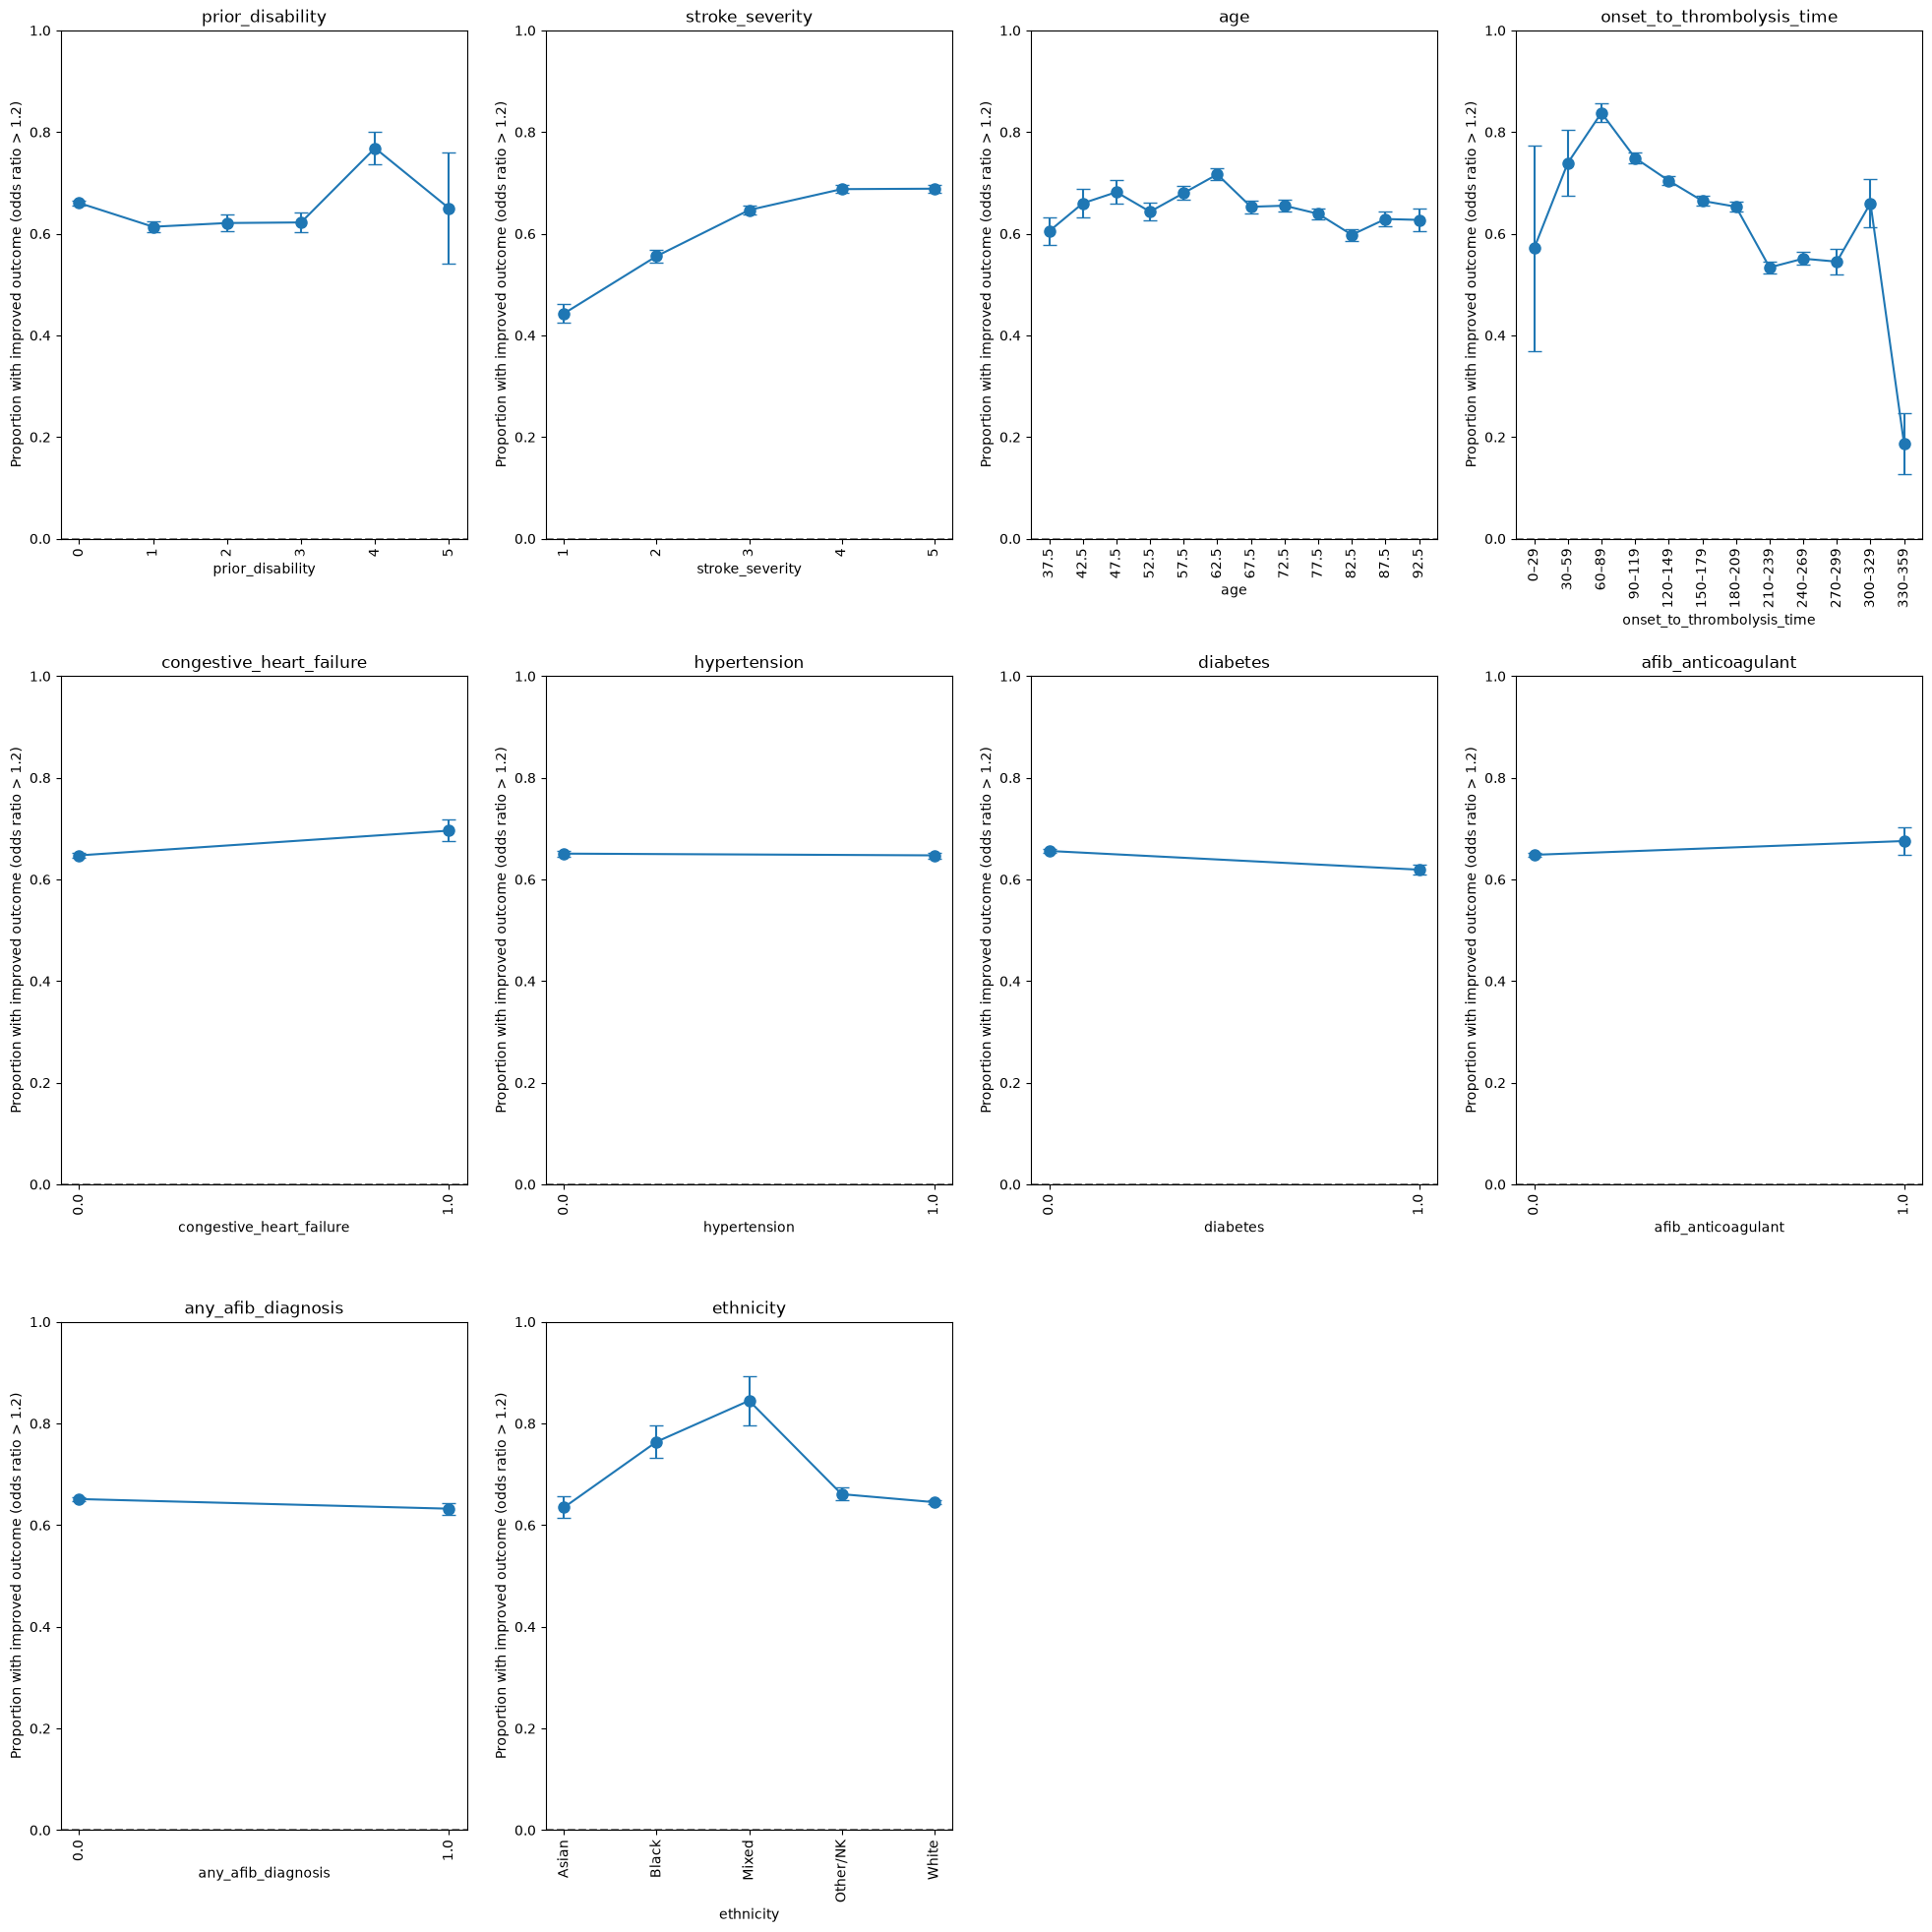

In [21]:
features_to_plot = [
    "prior_disability",
    "stroke_severity",
    "age",
    "onset_to_thrombolysis_time",
    "congestive_heart_failure",
    "hypertension",
    "diabetes",
    "afib_anticoagulant",
    "any_afib_diagnosis",
    "ethnicity",
]

fig, axes = plt.subplots(3, 4, figsize=(20, 20))

for i, feature in enumerate(features_to_plot):
    row, col = divmod(i, 4)
    ax = axes[row, col]

    plot_df = counter_factuals_df[
        [feature, "improved"]
    ].rename(
        columns={
            feature: "feature_value",
            "improved": "improved",
        }
    ).dropna()

    grouped = (
        plot_df.groupby("feature_value", observed=True)["improved"]
        .agg(mean="mean", sem="sem")
    )

    if feature == "stroke_team":
        grouped = grouped.sort_values("mean", ascending=False)

    # If feature is onset_to_thrombolysis_time, bin by 30 minutes
    if feature == "onset_to_thrombolysis_time":
        plot_df["feature_value"] = (
            pd.to_numeric(plot_df["feature_value"]) // 30 * 30
        ).astype(int)

        grouped = (
            plot_df.groupby("feature_value", observed=True)["improved"]
            .agg(mean="mean", sem="sem")
        )

        order = sorted(plot_df["feature_value"].unique())
        time_labels = [
            f"{start}–{start + 29}" for start in order]

    x_values = np.arange(len(grouped))
    labels = [str(value) for value in grouped.index]

    ax.errorbar(
        x_values,
        grouped["mean"],
        yerr=grouped["sem"],
        fmt="o-",
        markersize=8,
        capsize=5,
    )

    ax.set_title(f"{feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Proportion with improved outcome (odds ratio > 1.2)")
    ax.set_xticks(x_values)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)

    if feature == "stroke_team":
        ax.set_xticklabels([])
    elif feature == "stroke_severity":
        ax.set_xticklabels(
            [f"{float(label):.0f}" for label in labels]
        )
    elif feature == "onset_to_thrombolysis_time":
        ax.set_xticklabels(time_labels)
    else:
        ax.set_xticklabels(labels)

for j in range(len(features_to_plot), axes.size):
    axes.flat[j].axis("off")

plt.tight_layout(pad=2)
plt.savefig(
    f"./output/s_learner_improvement_{mrs_target}.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()